In [1]:
import os
import pandas as pd
DATA_PATH  = os.listdir()
df = pd.read_csv(DATA_PATH[0])
for i in DATA_PATH[1:7]:
    df = pd.concat([df, pd.read_csv(i)])
df.dropna(inplace=True)
display(df.info())
df.drop_duplicates(inplace=True)
display(df.info())
df_2=pd.read_csv("labeled_progress_5.csv")
df_add = df_2.iloc[:5320]
display(df_add.iloc[-1])
df = pd.concat([df_add, df])
df.dropna(inplace=True)
display(df.info())
df.drop_duplicates(inplace=True)
display(df.info())  

<class 'pandas.core.frame.DataFrame'>
Index: 3704 entries, 0 to 563
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   rating      3704 non-null   object
 1   text        3704 non-null   object
 2   word_count  3704 non-null   int64 
 3   food        3704 non-null   int64 
 4   service     3704 non-null   int64 
 5   place       3704 non-null   int64 
 6   cost        3704 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 231.5+ KB


None

<class 'pandas.core.frame.DataFrame'>
Index: 3650 entries, 0 to 563
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   rating      3650 non-null   object
 1   text        3650 non-null   object
 2   word_count  3650 non-null   int64 
 3   food        3650 non-null   int64 
 4   service     3650 non-null   int64 
 5   place       3650 non-null   int64 
 6   cost        3650 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 228.1+ KB


None

rating                                        5 sao
text          quán đồ ăn ngon, nhân viên nhiệt tình
word_count                                        8
food                                              2
service                                           2
place                                             0
cost                                              0
Name: 5319, dtype: object

<class 'pandas.core.frame.DataFrame'>
Index: 8970 entries, 0 to 563
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   rating      8970 non-null   object
 1   text        8970 non-null   object
 2   word_count  8970 non-null   int64 
 3   food        8970 non-null   int64 
 4   service     8970 non-null   int64 
 5   place       8970 non-null   int64 
 6   cost        8970 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 560.6+ KB


None

<class 'pandas.core.frame.DataFrame'>
Index: 8666 entries, 0 to 563
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   rating      8666 non-null   object
 1   text        8666 non-null   object
 2   word_count  8666 non-null   int64 
 3   food        8666 non-null   int64 
 4   service     8666 non-null   int64 
 5   place       8666 non-null   int64 
 6   cost        8666 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 541.6+ KB


None

In [2]:
display(df.head())

,rating,text,word_count,food,service,place,cost
0,4 sao,"món ăn ngon nhưng phải chờ quá lâu, và ngộ đời...",93,2,1,2,2
1,5 sao,bữa ăn ngon dịch vụ tốt các bạn nhân viên nhiệ...,20,2,2,0,0
2,5 sao,"không gian ấm cúng sang trọng , đồ ăn ngon , n...",22,2,2,2,2
3,5 sao,"đồ ăn ngon đó nhé, giá cả quá ư là hợp lý luôn",13,2,0,0,2
4,5 sao,"đồ ăn ngon, phục vụ nhiệt tình, thân thiện, kh...",32,2,2,2,0


count    8666.000000
mean       33.869028
std        45.412971
min         1.000000
25%        11.000000
50%        19.000000
75%        38.000000
max       772.000000
Name: word_count, dtype: float64


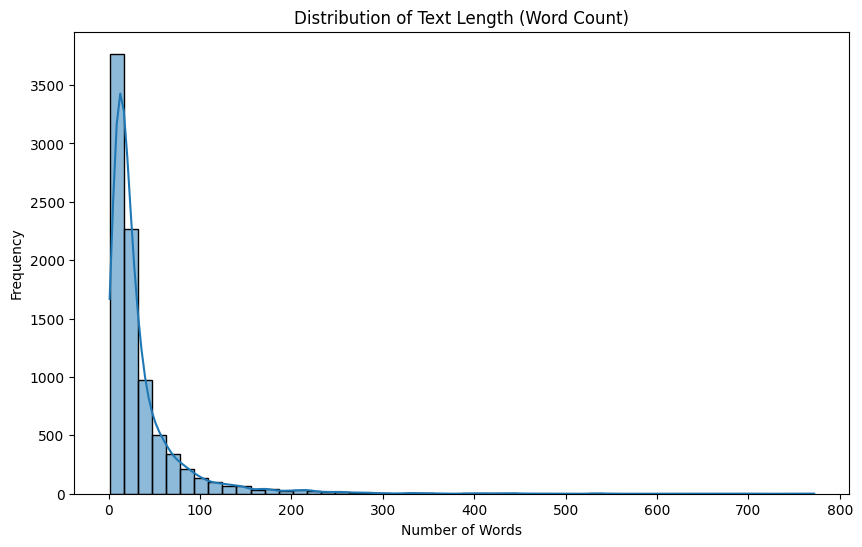

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create word count column
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))

# Basic statistics (optional but useful)
print(df["word_count"].describe())

# Plot histogram
plt.figure(figsize=(10,6))
sns.histplot(df["word_count"], bins=50, kde=True)

plt.title("Distribution of Text Length (Word Count)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

Word Count Statistics:
count    8666.000000
mean       33.869028
std        45.412971
min         1.000000
25%        11.000000
50%        19.000000
75%        38.000000
max       772.000000
Name: word_count, dtype: float64


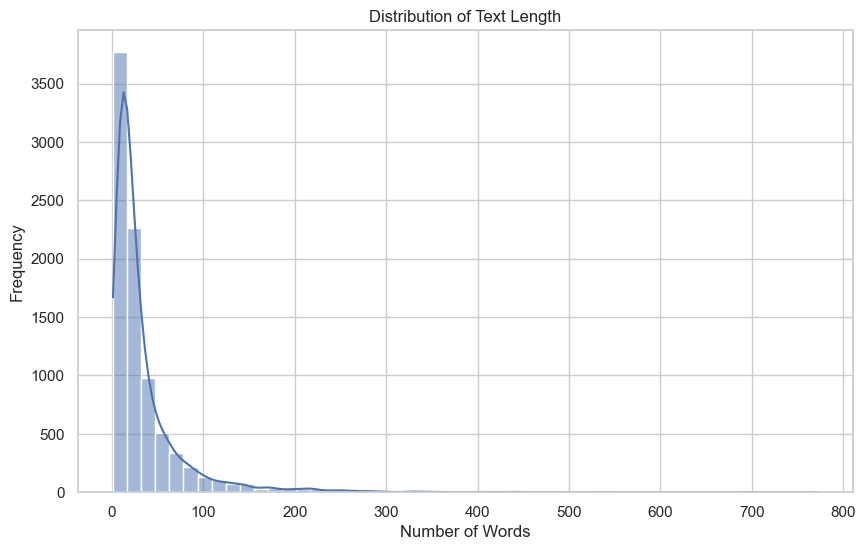


Coverage by Word Limit:
   limit   coverage
0     20  52.573275
1     30  68.497577
2     40  77.071313
3     50  82.217863
4     60  86.037387
5     80  90.872375
6    100  93.941842


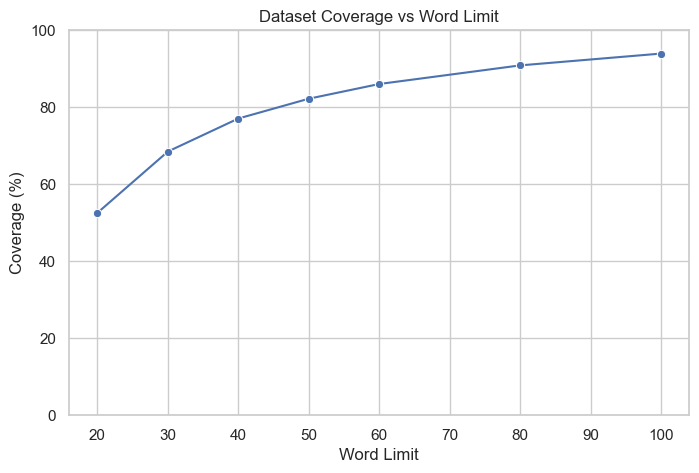


Recommended max sequence length: nan

Number of existing classes: 175


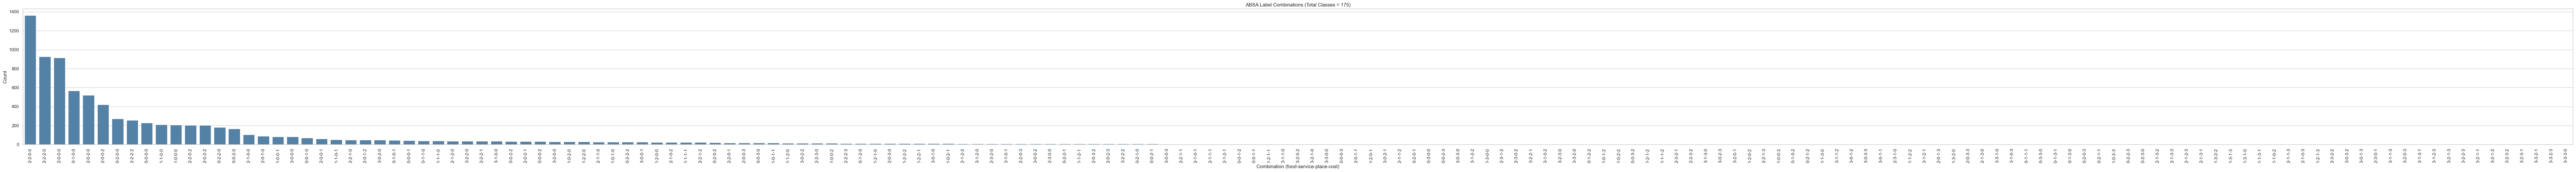

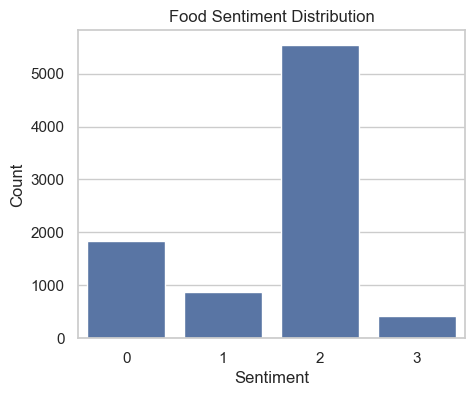

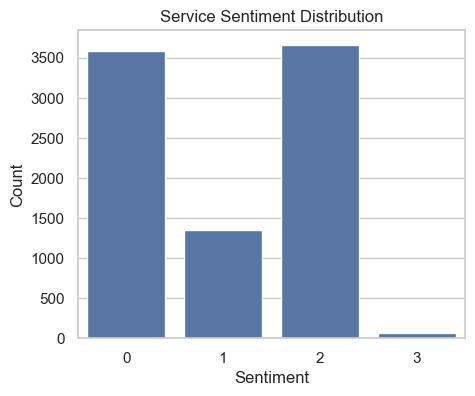

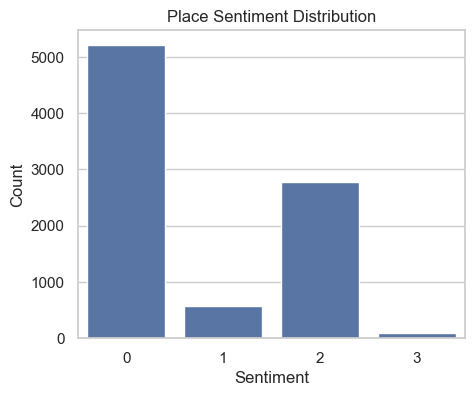

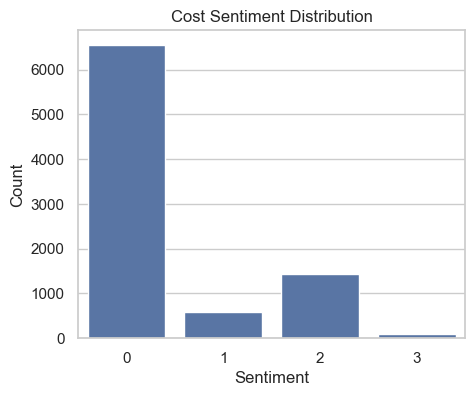

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# -------------------------------
# WORD COUNT ANALYSIS
# -------------------------------

# Create word count column
df["word_count"] = df["text"].astype(str).str.split().str.len()

print("Word Count Statistics:")
print(df["word_count"].describe())

# Histogram
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="word_count", bins=50, kde=True)

plt.title("Distribution of Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()


# -------------------------------
# WORD LIMIT COVERAGE
# -------------------------------

limits = [20, 30, 40, 50, 60, 80, 100]
coverage = []

for limit in limits:
    pct = (df["word_count"] <= limit).mean() * 100
    coverage.append(pct)

coverage_df = pd.DataFrame({
    "limit": limits,
    "coverage": coverage
})

print("\nCoverage by Word Limit:")
print(coverage_df)

plt.figure(figsize=(8,5))
sns.lineplot(data=coverage_df, x="limit", y="coverage", marker="o")

plt.title("Dataset Coverage vs Word Limit")
plt.xlabel("Word Limit")
plt.ylabel("Coverage (%)")
plt.ylim(0,100)

plt.show()

best_limit = coverage_df[coverage_df["coverage"] >= 95]["limit"].min()
print("\nRecommended max sequence length:", best_limit)


# -------------------------------
# ABSA LABEL COMBINATION ANALYSIS
# -------------------------------

counts = (
    df.value_counts(subset=["food","service","place","cost"])
      .reset_index(name="count")
)

num_classes = counts.shape[0]
print("\nNumber of existing classes:", num_classes)

# Create combination label
counts["combo"] = (
    counts[["food","service","place","cost"]]
    .astype(str)
    .agg("-".join, axis=1)
)

counts = counts.sort_values("count", ascending=False)

# Dynamic width depending on number of classes
width = max(12, num_classes * 0.5)

plt.figure(figsize=(width,6))
sns.barplot(data=counts, x="combo", y="count", color="steelblue")

plt.xticks(rotation=90)
plt.xlabel("Combination (food-service-place-cost)")
plt.ylabel("Count")
plt.title(f"ABSA Label Combinations (Total Classes = {num_classes})")

plt.tight_layout()
plt.show()


# -------------------------------
# INDIVIDUAL ASPECT DISTRIBUTION
# -------------------------------

aspects = ["food","service","place","cost"]

for aspect in aspects:
    plt.figure(figsize=(5,4))
    sns.countplot(data=df, x=aspect)

    plt.title(f"{aspect.capitalize()} Sentiment Distribution")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")

    plt.show()

Best threshold: 88


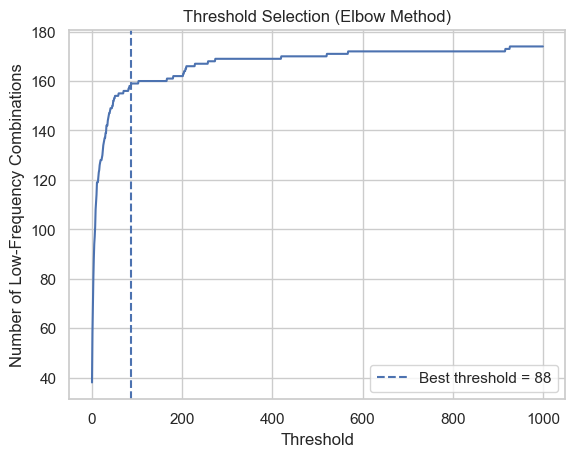

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Count combinations
counts = (
    df.value_counts(subset=["food","service","place","cost"])
      .reset_index(name="count")
)

thresholds = np.arange(1, 1000)

low_freq_counts = []
for t in thresholds:
    low_freq_counts.append((counts["count"] <= t).sum())

low_freq_counts = np.array(low_freq_counts)

# Normalize for knee detection
x = (thresholds - thresholds.min()) / (thresholds.max() - thresholds.min())
y = (low_freq_counts - low_freq_counts.min()) / (low_freq_counts.max() - low_freq_counts.min())

# Distance from diagonal line
distances = y - x
best_idx = np.argmax(distances)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)

# Plot
plt.figure()
plt.plot(thresholds, low_freq_counts)
plt.axvline(best_threshold, linestyle="--", label=f"Best threshold = {best_threshold}")
plt.xlabel("Threshold")
plt.ylabel("Number of Low-Frequency Combinations")
plt.title("Threshold Selection (Elbow Method)")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
import pandas as pd

# Count combinations
counts = (
    df.value_counts(subset=["food", "service", "place", "cost"])
      .reset_index(name="count")
)

threshold = best_threshold

# Merge counts with original data (keeps text)
df_with_counts = df.merge(counts, on=["food", "service", "place", "cost"])

# Filter low-frequency rows
low_freq = df_with_counts[df_with_counts["count"] <= threshold]

# Sort so lowest frequency appears first
low_freq = low_freq.sort_values(by="count", ascending=True)

# Save
low_freq.to_csv("low_frequency_classes.csv", index=False)

In [7]:
df.to_csv('labeled_data_10032026.csv', index=False)